# E-Commerce Growth and Customer Analytics

### Analyzing Sales Performance, Customer Experience, and Customer Retention

## Business Problem

An e-commerce business wants to understand how its sales performance, customer experience, and customer behavior have changed over time.

The business needs data-driven insights to answer several questions:

1. How is the business performing in terms of revenue and orders?
2. Which factors are associated with customer satisfaction?
3. Which customer segments generate the most value?
4. Which products and sellers contribute the most to revenue?
5. Which areas could be prioritized for business improvement?

This analysis uses historical e-commerce transaction data to identify patterns and provide recommendations that can support business decision making.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data_path = '../data/raw'

customers = pd.read_csv(os.path.join(data_path, 'customers_dataset.csv'))
orders = pd.read_csv(os.path.join(data_path, 'orders_dataset.csv'))
order_items = pd.read_csv(os.path.join(data_path, 'order_items_dataset.csv'))
payments = pd.read_csv(os.path.join(data_path, 'order_payments_dataset.csv'))
reviews = pd.read_csv(os.path.join(data_path, 'order_reviews_dataset.csv'))
products = pd.read_csv(os.path.join(data_path, 'products_dataset.csv'))
sellers = pd.read_csv(os.path.join(data_path, 'sellers_dataset.csv'))
geolocation = pd.read_csv(os.path.join(data_path, 'geolocation_dataset.csv'))
category_translation = pd.read_csv(
    os.path.join(data_path, 'product_category_name_translation.csv')
)

In [4]:
datasets = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation
}

for name, df in datasets.items():
    print(name, df.shape)

customers (99441, 5)
orders (99441, 8)
order_items (112650, 7)
payments (103886, 5)
reviews (99224, 7)
products (32951, 9)
sellers (3095, 4)
geolocation (1000163, 5)


## Data Quality Audit

Before combining the datasets, the data quality of each table is checked to identify:

- Missing values
- Duplicate rows
- Data types
- Potential issues in key columns

This step helps ensure that the analysis is based on clean and consistent data.

In [5]:
for name, df in datasets.items():
    print(f'\n{name}')
    print('Missing values:')
    print(df.isnull().sum())
    print('Duplicate rows:', df.duplicated().sum())


customers
Missing values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Duplicate rows: 0

orders
Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Duplicate rows: 0

order_items
Missing values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
Duplicate rows: 0

payments
Missing values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
Duplicate rows: 0

reviews
Mi

## Data Quality Summary

A compact summary is created to review missing values, duplicate rows, and data types across all datasets.

In [6]:
quality_summary = []

for name, df in datasets.items():
    quality_summary.append({
        'dataset': name,
        'rows': len(df),
        'columns': len(df.columns),
        'missing_values': df.isnull().sum().sum(),
        'duplicate_rows': df.duplicated().sum()
    })

quality_summary = pd.DataFrame(quality_summary)

quality_summary

,dataset,rows,columns,missing_values,duplicate_rows
0,customers,99441,5,0,0
1,orders,99441,8,4908,0
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
4,reviews,99224,7,145903,0
5,products,32951,9,2448,0
6,sellers,3095,4,0,0
7,geolocation,1000163,5,0,261831


In [7]:
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        print(f'\n{name}')
        print(missing)


orders
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64

products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


## Order Status Analysis

Before handling missing delivery dates, the order status distribution is reviewed to understand why some order timestamps may be unavailable.

In [8]:
order_status = (
    orders['order_status']
    .value_counts()
    .reset_index()
)

order_status.columns = ['order_status', 'order_count']

order_status

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [11]:
delivery_status = orders.groupby('order_status').agg(
    total_orders=('order_id', 'count')
).reset_index()

delivery_status['missing_carrier_date'] = (
    orders.groupby('order_status')['order_delivered_carrier_date']
    .apply(lambda x: x.isna().sum())
    .values
)

delivery_status['missing_customer_date'] = (
    orders.groupby('order_status')['order_delivered_customer_date']
    .apply(lambda x: x.isna().sum())
    .values
)

delivery_status

,order_status,total_orders,missing_carrier_date,missing_customer_date
0,approved,2,2,2
1,canceled,625,550,619
2,created,5,5,5
3,delivered,96478,2,8
4,invoiced,314,314,314
5,processing,301,301,301
6,shipped,1107,0,1107
7,unavailable,609,609,609


## Data Cleaning Rules

Missing delivery timestamps are not automatically removed or filled because their absence can be explained by the order status.

For delivery performance analysis, only orders with an actual delivery date will be used. This prevents undelivered or canceled orders from being incorrectly included in delivery-time calculations.

Review comment fields are kept as they are because customers may provide a rating without writing a comment.

Product records with missing category information will be handled separately when product category analysis is performed.

In [12]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

In [13]:
orders[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

## Delivery Performance Analysis

For delivery analysis, only completed orders are used.

Delivery time is calculated as the number of days between the order purchase date and the date the order was delivered to the customer.

In [14]:
delivery_df = orders[
    orders['order_delivered_customer_date'].notna()
].copy()

delivery_df['delivery_days'] = (
    delivery_df['order_delivered_customer_date']
    - delivery_df['order_purchase_timestamp']
).dt.days

delivery_df['late_delivery'] = (
    delivery_df['order_delivered_customer_date']
    > delivery_df['order_estimated_delivery_date']
)

delivery_df[
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'delivery_days',
        'late_delivery'
    ]
].head()

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8,False
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13,False
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9,False
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13,False
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2,False


## Customer Experience Analysis

Delivery performance is combined with customer reviews to examine whether delivery experience is associated with customer satisfaction.

In [15]:
delivery_review = delivery_df[
    ['order_id', 'delivery_days', 'late_delivery']
].merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

delivery_review.head()

,order_id,delivery_days,late_delivery,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8,False,4
1,53cdb2fc8bc7dce0b6741e2150273451,13,False,4
2,47770eb9100c2d0c44946d9cf07ec65d,9,False,5
3,949d5b44dbf5de918fe9c16f97b45f8a,13,False,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2,False,5


In [16]:
print('Rows:', len(delivery_review))
print('Columns:', len(delivery_review.columns))

Rows: 96359
Columns: 4


In [17]:
delivery_review.groupby('late_delivery')['review_score'].mean()

late_delivery
False    4.293578
True     2.566550
Name: review_score, dtype: float64

## Delivery Performance Summary

The average customer review score is compared between orders delivered on time and orders delivered after the estimated delivery date.

This analysis is used to identify whether delivery performance is associated with customer satisfaction.

In [18]:
delivery_summary = (
    delivery_review
    .groupby('late_delivery')
    .agg(
        orders=('order_id', 'count'),
        average_review=('review_score', 'mean')
    )
    .reset_index()
)

delivery_summary

,late_delivery,orders,average_review
0,False,88658,4.293578
1,True,7701,2.566550


In [19]:
delivery_summary['delivery_status'] = delivery_summary['late_delivery'].map({
    False: 'On Time',
    True: 'Late'
})

delivery_summary = delivery_summary[
    ['delivery_status', 'orders', 'average_review']
]

delivery_summary

,delivery_status,orders,average_review
0,On Time,88658,4.293578
1,Late,7701,2.566550


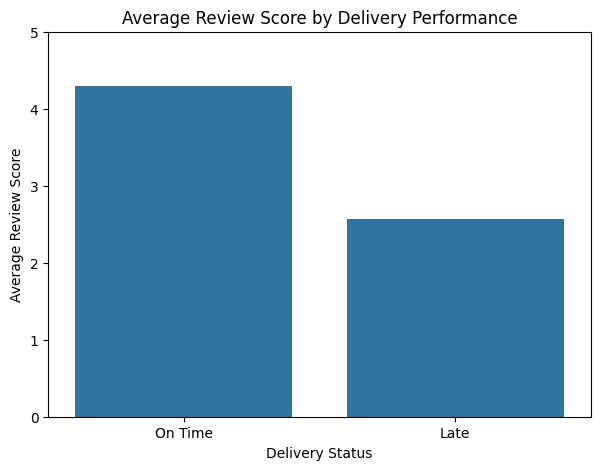

In [20]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=delivery_summary,
    x='delivery_status',
    y='average_review'
)

plt.title('Average Review Score by Delivery Performance')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)

plt.show()

## Business Finding

Orders delivered on time received an average review score of **4.29**, while late orders received an average score of **2.57**.

The difference of approximately **1.73 points** indicates a strong association between delivery performance and customer satisfaction in this dataset.

This suggests that improving delivery reliability could be an important area for improving customer experience. However, this analysis identifies an association rather than proving a causal relationship.

## Sales Performance Analysis

The sales analysis focuses on revenue and order performance over time.

Payment data may contain multiple records for the same order, so payment values are aggregated at the order level before being combined with the order data.

In [21]:
payments_order = (
    payments
    .groupby('order_id', as_index=False)['payment_value']
    .sum()
)

sales_df = orders[
    ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp']
].merge(
    payments_order,
    on='order_id',
    how='left'
)

sales_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,28.62


In [22]:
print('Total orders:', len(sales_df))
print('Orders without payment:', sales_df['payment_value'].isna().sum())

Total orders: 99441
Orders without payment: 1


In [23]:
sales_df['payment_value'].describe()

count    99440.000000
mean       160.990267
std        221.951257
min          0.000000
25%         62.010000
50%        105.290000
75%        176.970000
max      13664.080000
Name: payment_value, dtype: float64

## Sales Performance Overview

The first step is to establish the main sales KPIs used throughout the analysis.

The metrics include total revenue, total orders, total customers, and average order value.

In [24]:
sales_kpi = {
    'total_revenue': sales_df['payment_value'].sum(),
    'total_orders': sales_df['order_id'].nunique(),
    'total_customers': sales_df['customer_id'].nunique(),
    'average_order_value': sales_df['payment_value'].mean()
}

sales_kpi

{'total_revenue': np.float64(16008872.120000001),
 'total_orders': 99441,
 'total_customers': 99441,
 'average_order_value': np.float64(160.9902666934835)}

In [25]:
print('Total Revenue:', round(sales_kpi['total_revenue'], 2))
print('Total Orders:', sales_kpi['total_orders'])
print('Total Customers:', sales_kpi['total_customers'])
print('Average Order Value:', round(sales_kpi['average_order_value'], 2))

Total Revenue: 16008872.12
Total Orders: 99441
Total Customers: 99441
Average Order Value: 160.99


## Monthly Sales Performance

Monthly revenue and order volume are analyzed to identify trends and changes in sales performance over time.

In [26]:
sales_df['year_month'] = (
    sales_df['order_purchase_timestamp']
    .dt.to_period('M')
    .astype(str)
)

sales_monthly = (
    sales_df
    .groupby('year_month')
    .agg(
        revenue=('payment_value', 'sum'),
        orders=('order_id', 'nunique'),
        customers=('customer_id', 'nunique')
    )
    .reset_index()
)

sales_monthly['aov'] = (
    sales_monthly['revenue'] /
    sales_monthly['orders']
)

sales_monthly.head()

,year_month,revenue,orders,customers,aov
0,2016-09,252.24,4,4,63.060000
1,2016-10,59090.48,324,324,182.378025
2,2016-12,19.62,1,1,19.620000
3,2017-01,138488.04,800,800,173.110050
4,2017-02,291908.01,1780,1780,163.993264


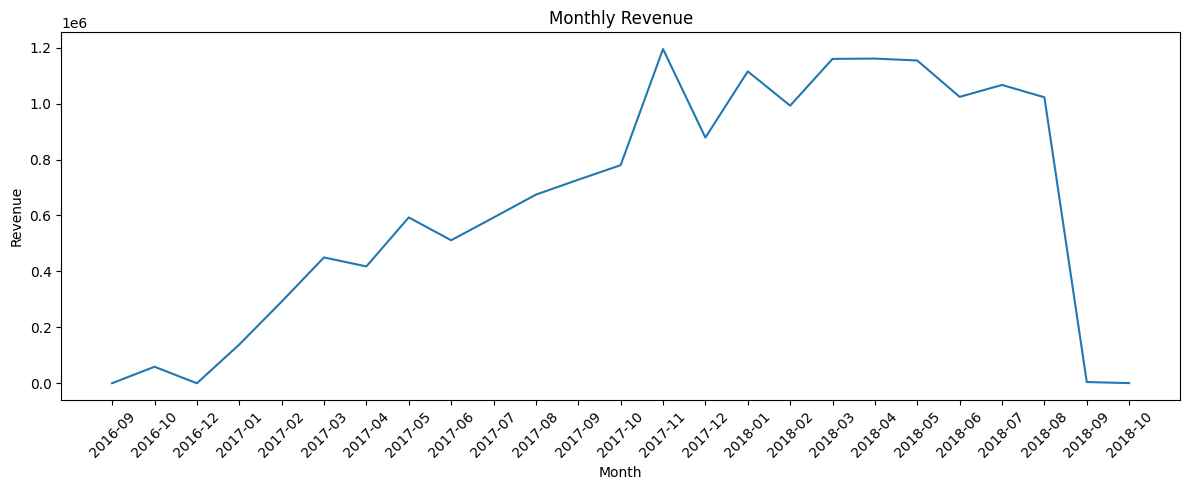

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    sales_monthly['year_month'],
    sales_monthly['revenue']
)

ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue')

plt.xticks(rotation=45)
plt.title('Monthly Revenue')
plt.tight_layout()
plt.show()

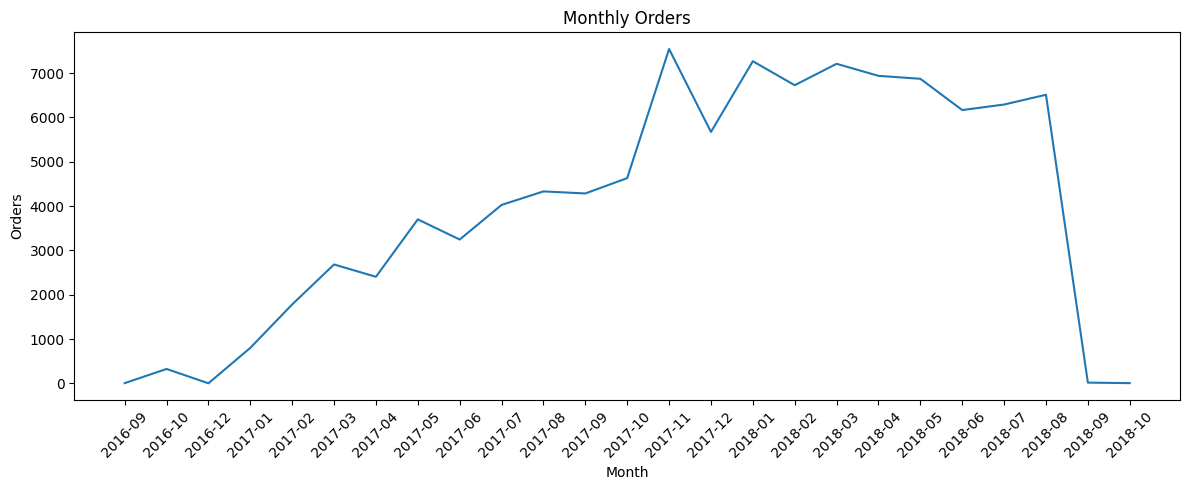

In [29]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=sales_monthly,
    x='year_month',
    y='orders'
)

plt.title('Monthly Orders')
plt.xlabel('Month')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
sales_monthly['revenue_growth'] = (
    sales_monthly['revenue']
    .pct_change() * 100
)

sales_monthly['order_growth'] = (
    sales_monthly['orders']
    .pct_change() * 100
)

sales_monthly.tail()

,year_month,revenue,orders,customers,aov,revenue_growth,order_growth
20,2018-06,1023880.50,6167,6167,166.025701,-11.274148,-10.272079
21,2018-07,1066540.75,6292,6292,169.507430,4.166526,2.026917
22,2018-08,1022425.32,6512,6512,157.006345,-4.136310,3.496503
23,2018-09,4439.54,16,16,277.471250,-99.565783,-99.754300
24,2018-10,589.67,4,4,147.417500,-86.717768,-75.000000


## Sales Performance Highlights

The highest-performing months are identified based on revenue and order volume.

In [31]:
top_revenue_months = (
    sales_monthly
    .sort_values('revenue', ascending=False)
    .head(5)
)

top_order_months = (
    sales_monthly
    .sort_values('orders', ascending=False)
    .head(5)
)

print('Top 5 months by revenue:')
print(top_revenue_months[['year_month', 'revenue', 'orders', 'aov']])

print('\nTop 5 months by orders:')
print(top_order_months[['year_month', 'orders', 'revenue', 'aov']])

Top 5 months by revenue:
   year_month     revenue  orders         aov
13    2017-11  1194882.80    7544  158.388494
18    2018-04  1160785.48    6939  167.284260
17    2018-03  1159652.12    7211  160.817102
19    2018-05  1153982.15    6873  167.900793
15    2018-01  1115004.18    7269  153.391688

Top 5 months by orders:
   year_month  orders     revenue         aov
13    2017-11    7544  1194882.80  158.388494
15    2018-01    7269  1115004.18  153.391688
17    2018-03    7211  1159652.12  160.817102
18    2018-04    6939  1160785.48  167.284260
19    2018-05    6873  1153982.15  167.900793


In [32]:
os.makedirs('../data/processed', exist_ok=True)

sales_monthly.to_csv(
    '../data/processed/sales_monthly.csv',
    index=False
)

print('sales_monthly.csv saved successfully.')

sales_monthly.csv saved successfully.


## Sales Trend Insight

The monthly analysis shows that sales performance varies across the observed period.

November 2017 generated the highest monthly revenue at 1.19 million, supported by the highest order volume of 7,544 orders among the top-performing months.

Meanwhile, May 2018 recorded the highest average order value among the top five revenue months at 167.90.

This indicates that sales performance should be evaluated using both transaction volume and average order value, rather than relying on revenue alone.

In [33]:
first_month = sales_monthly.iloc[0]
last_month = sales_monthly.iloc[-1]

revenue_growth = (
    (last_month['revenue'] - first_month['revenue'])
    / first_month['revenue']
) * 100

order_growth = (
    (last_month['orders'] - first_month['orders'])
    / first_month['orders']
) * 100

print('First month:', first_month['year_month'])
print('Last month:', last_month['year_month'])
print('Revenue growth:', round(revenue_growth, 2), '%')
print('Order growth:', round(order_growth, 2), '%')

First month: 2016-09
Last month: 2018-10
Revenue growth: 133.77 %
Order growth: 0.0 %


In [34]:
sales_monthly[
    sales_monthly['year_month'].isin([
        sales_monthly.iloc[0]['year_month'],
        sales_monthly.iloc[-1]['year_month']
    ])
]

,year_month,revenue,orders,customers,aov,revenue_growth,order_growth
0,2016-09,252.24,4,4,63.0600,NaN,NaN
24,2018-10,589.67,4,4,147.4175,-86.717768,-75.0


In [35]:
orders_monthly_check = sales_monthly[
    ['year_month', 'orders', 'revenue']
].iloc[[0, -1]]

orders_monthly_check

,year_month,orders,revenue
0,2016-09,4,252.24
24,2018-10,4,589.67


## Monthly Sales Performance

The dataset covers an extended period, but the first and last recorded months contain only a small number of orders.

To avoid misleading comparisons, monthly performance is evaluated across the core period rather than using the first and last recorded month as a direct growth comparison.

In [36]:
monthly_order_check = (
    sales_df
    .groupby('year_month')['order_id']
    .nunique()
    .reset_index(name='orders')
)

monthly_order_check.sort_values('orders').head()

,year_month,orders
2,2016-12,1
0,2016-09,4
24,2018-10,4
23,2018-09,16
1,2016-10,324


In [37]:
highest_revenue_growth = (
    sales_monthly
    .dropna(subset=['revenue_growth'])
    .sort_values('revenue_growth', ascending=False)
    .head(5)
)

lowest_revenue_growth = (
    sales_monthly
    .dropna(subset=['revenue_growth'])
    .sort_values('revenue_growth')
    .head(5)
)

print('Highest monthly revenue growth:')
print(
    highest_revenue_growth[
        ['year_month', 'revenue', 'revenue_growth']
    ]
)

print('\nLowest monthly revenue growth:')
print(
    lowest_revenue_growth[
        ['year_month', 'revenue', 'revenue_growth']
    ]
)

Highest monthly revenue growth:
   year_month     revenue  revenue_growth
3     2017-01   138488.04   705751.376147
1     2016-10    59090.48    23326.292420
4     2017-02   291908.01      110.782108
5     2017-03   449863.60       54.111427
13    2017-11  1194882.80       53.253392

Lowest monthly revenue growth:
   year_month    revenue  revenue_growth
2     2016-12      19.62      -99.966797
23    2018-09    4439.54      -99.565783
24    2018-10     589.67      -86.717768
14    2017-12  878401.48      -26.486390
8     2017-06  511276.38      -13.769581


## Core Sales Period

The dataset contains several partial months with very low order volume at the beginning and end of the observation period.

To make monthly comparisons more meaningful, the core sales analysis focuses on months with at least 1,000 orders.

In [38]:
core_sales = sales_monthly[
    sales_monthly['orders'] >= 1000
].copy()

core_sales.head()

,year_month,revenue,orders,customers,aov,revenue_growth,order_growth
4,2017-02,291908.01,1780,1780,163.993264,110.782108,122.500000
5,2017-03,449863.60,2682,2682,167.734377,54.111427,50.674157
6,2017-04,417788.03,2404,2404,173.788698,-7.130066,-10.365399
7,2017-05,592918.82,3700,3700,160.248330,41.918575,53.910150
8,2017-06,511276.38,3245,3245,157.558206,-13.769581,-12.297297


In [39]:
print('Start:', core_sales['year_month'].min())
print('End:', core_sales['year_month'].max())
print('Number of months:', len(core_sales))

Start: 2017-02
End: 2018-08
Number of months: 19


In [40]:
core_sales['revenue_growth'] = (
    core_sales['revenue'].pct_change() * 100
)

core_sales['order_growth'] = (
    core_sales['orders'].pct_change() * 100
)

core_sales[
    ['year_month', 'revenue', 'orders', 'aov',
     'revenue_growth', 'order_growth']
].head(10)

,year_month,revenue,orders,aov,revenue_growth,order_growth
4,2017-02,291908.01,1780,163.993264,NaN,NaN
5,2017-03,449863.60,2682,167.734377,54.111427,50.674157
6,2017-04,417788.03,2404,173.788698,-7.130066,-10.365399
7,2017-05,592918.82,3700,160.248330,41.918575,53.910150
8,2017-06,511276.38,3245,157.558206,-13.769581,-12.297297
9,2017-07,592382.92,4026,147.139324,15.863541,24.067797
10,2017-08,674396.32,4331,155.713766,13.844660,7.575758
11,2017-09,727762.45,4285,169.839545,7.913170,-1.062110
12,2017-10,779677.88,4631,168.360587,7.133568,8.074679
13,2017-11,1194882.80,7544,158.388494,53.253392,62.902181


In [41]:
top_core_revenue = (
    core_sales
    .sort_values('revenue', ascending=False)
    .head(5)
)

top_core_revenue[
    ['year_month', 'revenue', 'orders', 'aov']
]

,year_month,revenue,orders,aov
13,2017-11,1194882.80,7544,158.388494
18,2018-04,1160785.48,6939,167.284260
17,2018-03,1159652.12,7211,160.817102
19,2018-05,1153982.15,6873,167.900793
15,2018-01,1115004.18,7269,153.391688


In [42]:
core_sales.to_csv(
    '../data/processed/sales_monthly.csv',
    index=False
)

print('sales_monthly.csv saved successfully.')

sales_monthly.csv saved successfully.


## Revenue Drivers

Revenue performance can be influenced by the number of orders and the average value of each order.

This analysis compares monthly revenue, order volume, and average order value to understand which factors are associated with stronger sales performance.

In [43]:
core_sales['revenue_per_order'] = (
    core_sales['revenue'] / core_sales['orders']
)

core_sales[
    ['year_month', 'revenue', 'orders', 'aov']
].sort_values('revenue', ascending=False).head(10)

,year_month,revenue,orders,aov
13,2017-11,1194882.80,7544,158.388494
18,2018-04,1160785.48,6939,167.284260
17,2018-03,1159652.12,7211,160.817102
19,2018-05,1153982.15,6873,167.900793
15,2018-01,1115004.18,7269,153.391688
21,2018-07,1066540.75,6292,169.507430
20,2018-06,1023880.50,6167,166.025701
22,2018-08,1022425.32,6512,157.006345
16,2018-02,992463.34,6728,147.512387
14,2017-12,878401.48,5673,154.838971


In [44]:
top_aov = (
    core_sales
    .sort_values('aov', ascending=False)
    .head(5)
)

top_aov[
    ['year_month', 'revenue', 'orders', 'aov']
]

,year_month,revenue,orders,aov
6,2017-04,417788.03,2404,173.788698
11,2017-09,727762.45,4285,169.839545
21,2018-07,1066540.75,6292,169.507430
12,2017-10,779677.88,4631,168.360587
19,2018-05,1153982.15,6873,167.900793


## Sales Performance Finding

Within the core analysis period, November 2017 generated the highest monthly revenue at 1.19 million with 7,544 orders.

However, the highest average order value was recorded in April 2017 at 173.79, even though its total revenue was lower than the top-performing revenue months.

This suggests that overall revenue performance is influenced by both transaction volume and the value of each order. Therefore, both order volume and average order value should be monitored when evaluating sales performance.

# Customer Analytics

## RFM Customer Segmentation

RFM analysis is used to understand customer purchasing behavior based on three dimensions:

- **Recency** — how recently a customer made a purchase.
- **Frequency** — how often a customer made a purchase.
- **Monetary** — how much a customer spent.

The analysis is used to identify customer segments with different business priorities.

In [45]:
reference_date = orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

print('Reference date:', reference_date)

Reference date: 2018-10-18 17:30:18


## Customer Transaction Data

Customer purchasing behavior is aggregated at the customer level.

The analysis uses completed transaction records to calculate Recency, Frequency, and Monetary value.

In [46]:
customer_transactions = sales_df[
    sales_df['payment_value'].notna()
].copy()

customer_transactions = customer_transactions[
    customer_transactions['order_status'] == 'delivered'
].copy()

customer_transactions.head()

,order_id,customer_id,order_status,order_purchase_timestamp,payment_value,year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,38.71,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,141.46,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,179.12,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,72.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,28.62,2018-02


In [47]:
rfm = (
    customer_transactions
    .groupby('customer_id')
    .agg(
        last_purchase=('order_purchase_timestamp', 'max'),
        frequency=('order_id', 'nunique'),
        monetary=('payment_value', 'sum')
    )
    .reset_index()
)

rfm['recency'] = (
    reference_date - rfm['last_purchase']
).dt.days

rfm.head()

,customer_id,last_purchase,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,1,114.74,338
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,1,67.41,459
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,1,195.42,597
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,1,179.35,428
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,1,107.01,199


## RFM Summary

The distribution of Recency, Frequency, and Monetary values is reviewed before assigning customer segments.

In [61]:
customer_transactions = (
    sales_df[
        (sales_df['payment_value'].notna()) &
        (sales_df['order_status'] == 'delivered')
    ]
    .merge(
        customers[['customer_id', 'customer_unique_id']],
        on='customer_id',
        how='left'
    )
)

print('Rows:', len(customer_transactions))
print('Unique customers:', customer_transactions['customer_unique_id'].nunique())

Rows: 96477
Unique customers: 93357


In [62]:
customer_order_count = (
    customer_transactions
    .groupby('customer_unique_id')['order_id']
    .nunique()
)

print('Customers with more than one order:',
      (customer_order_count > 1).sum())

print('Maximum orders by one customer:',
      customer_order_count.max())

Customers with more than one order: 2801
Maximum orders by one customer: 15


In [63]:
rfm = (
    customer_transactions
    .groupby('customer_unique_id')
    .agg(
        last_purchase=('order_purchase_timestamp', 'max'),
        frequency=('order_id', 'nunique'),
        monetary=('payment_value', 'sum')
    )
    .reset_index()
)

rfm['recency'] = (
    reference_date - rfm['last_purchase']
).dt.days

rfm.head()

,customer_unique_id,last_purchase,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,161
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,164
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,586
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,370
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,337


In [64]:
rfm[['recency', 'frequency', 'monetary']].describe()

,recency,frequency,monetary
count,93357.000000,93357.000000,93357.000000
mean,287.100367,1.033420,165.198772
std,152.584573,0.209099,226.314579
min,50.000000,1.000000,9.590000
25%,164.000000,1.000000,63.060000
50%,268.000000,1.000000,107.780000
75%,395.000000,1.000000,182.560000
max,745.000000,15.000000,13664.080000


## RFM Scoring

Customers are scored based on the distribution of their Recency, Frequency, and Monetary values.

Each metric is divided into five groups:

- Recency: more recent purchases receive higher scores.
- Frequency: customers with more orders receive higher scores.
- Monetary: customers with higher spending receive higher scores.

The scoring is based on the customer distribution rather than fixed business thresholds.

In [65]:
rfm['r_score'] = pd.qcut(
    rfm['recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm['f_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['m_score'] = pd.qcut(
    rfm['monetary'],
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)

rfm.head()

,customer_unique_id,last_purchase,frequency,monetary,recency,r_score,f_score,m_score
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,1,141.90,161,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,1,27.19,164,4,1,1
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,1,86.22,586,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,1,43.62,370,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,1,196.89,337,2,1,4


In [66]:
rfm['rfm_score'] = (
    rfm['r_score'] +
    rfm['f_score'] +
    rfm['m_score']
)

rfm[['customer_unique_id', 'recency', 'frequency',
     'monetary', 'r_score', 'f_score', 'm_score',
     'rfm_score']].head()

,customer_unique_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,6
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,4
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,4
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,7


In [67]:
rfm['rfm_score'].value_counts().sort_index()

rfm_score
3       799
4      2365
5      4697
6      7578
7     11100
8     13313
9     13986
10    13151
11    10888
12     7464
13     4583
14     2433
15     1000
Name: count, dtype: int64

## Customer Segmentation

Customers are grouped into segments based on their RFM scores to identify different business priorities.

The segments are designed to distinguish high-value customers, promising customers, and customers who may require reactivation.

In [79]:
median_recency = rfm['recency'].median()
median_monetary = rfm['monetary'].median()

def assign_segment(row):
    if (
        row['frequency'] >= 2 and
        row['r_score'] >= 4 and
        row['m_score'] >= 4
    ):
        return 'Champions'

    elif row['frequency'] >= 2:
        return 'Loyal Customers'

    elif (
        row['recency'] > median_recency and
        row['monetary'] >= median_monetary
    ):
        return 'At Risk'

    elif row['recency'] > median_recency:
        return 'Hibernating'

    else:
        return 'New / Potential'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

rfm['segment'].value_counts()

segment
New / Potential    45252
Hibernating        23521
At Risk            21783
Loyal Customers     1812
Champions            989
Name: count, dtype: int64

In [80]:
customer_segment_summary = (
    rfm
    .groupby('segment')
    .agg(
        customers=('customer_unique_id', 'count'),
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
        avg_monetary=('monetary', 'mean'),
        total_revenue=('monetary', 'sum')
    )
    .reset_index()
)

customer_segment_summary['revenue_share'] = (
    customer_segment_summary['total_revenue']
    / customer_segment_summary['total_revenue'].sum()
    * 100
)

customer_segment_summary.sort_values(
    'total_revenue',
    ascending=False
)

,segment,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_share
4,New / Potential,45252,161.179462,1.000000,161.702146,7317345.50,47.446028
0,At Risk,21783,413.766745,1.000000,263.643120,5742938.08,37.237493
2,Hibernating,23521,414.154458,1.000000,63.680157,1497820.98,9.711945
3,Loyal Customers,1812,341.251104,2.076159,273.787699,496103.31,3.216758
1,Champions,989,137.897877,2.183013,372.349747,368253.90,2.387776


In [81]:
repeat_rate = (
    rfm
    .groupby('segment')['frequency']
    .apply(lambda x: (x > 1).mean() * 100)
    .reset_index(name='repeat_customer_rate')
)

repeat_rate.sort_values(
    'repeat_customer_rate',
    ascending=False
)

,segment,repeat_customer_rate
1,Champions,100.0
3,Loyal Customers,100.0
0,At Risk,0.0
2,Hibernating,0.0
4,New / Potential,0.0


In [82]:
customer_segment_summary = customer_segment_summary.merge(
    repeat_rate,
    on='segment',
    how='left'
)

customer_segment_summary.sort_values(
    'total_revenue',
    ascending=False
)

,segment,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_share,repeat_customer_rate
4,New / Potential,45252,161.179462,1.000000,161.702146,7317345.50,47.446028,0.0
0,At Risk,21783,413.766745,1.000000,263.643120,5742938.08,37.237493,0.0
2,Hibernating,23521,414.154458,1.000000,63.680157,1497820.98,9.711945,0.0
3,Loyal Customers,1812,341.251104,2.076159,273.787699,496103.31,3.216758,100.0
1,Champions,989,137.897877,2.183013,372.349747,368253.90,2.387776,100.0


In [83]:
rfm.to_csv(
    '../data/processed/customer_rfm.csv',
    index=False
)


## Product Performance

Product-level performance is analyzed to identify categories that contribute most to sales and order volume.

In [84]:
product_sales = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

product_sales = product_sales.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

product_sales = product_sales.merge(
    payments_order,
    on='order_id',
    how='left'
)

category_performance = (
    product_sales
    .groupby('product_category_name_english')
    .agg(
        orders=('order_id', 'nunique'),
        items_sold=('order_item_id', 'count'),
        revenue=('payment_value', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

category_performance.head(10)

,product_category_name_english,orders,items_sold,revenue
7,bed_bath_table,9417,11115,1712553.67
43,health_beauty,8836,9670,1657373.12
15,computers_accessories,6689,7827,1585330.45
39,furniture_decor,6449,8334,1430176.39
70,watches_gifts,5624,5991,1429216.68
65,sports_leisure,7720,8641,1392127.56
49,housewares,5884,6964,1094758.13
5,auto,3897,4235,852294.33
42,garden_tools,3518,4347,838280.75
20,cool_stuff,3632,3796,779698.00


In [86]:
seller_performance = (
    order_items
    .groupby('seller_id')
    .agg(
        orders=('order_id', 'nunique'),
        items_sold=('order_item_id', 'count'),
        revenue=('price', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

seller_performance.head(10)

,seller_id,orders,items_sold,revenue
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63
1013,53243585a1d6dc2643021fd1853d8905,358,410,222776.05
881,4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03
1535,7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89
1560,7e93a43ef30c4f03f38b393420bc753a,336,340,176431.87
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55
1824,955fee9216a65b617aa5c0531780ce60,1287,1499,135171.70


In [87]:
category_performance.to_csv(
    '../data/processed/product_performance.csv',
    index=False
)

seller_performance.to_csv(
    '../data/processed/seller_performance.csv',
    index=False
)

print('Product and seller files saved successfully.')

Product and seller files saved successfully.


## Geographic Performance

Geographic performance is analyzed to identify regions with the highest order volume and revenue contribution.

In [88]:
geo_sales = sales_df[
    sales_df['payment_value'].notna()
].merge(
    customers[
        ['customer_id', 'customer_state']
    ],
    on='customer_id',
    how='left'
)

geographic_performance = (
    geo_sales
    .groupby('customer_state')
    .agg(
        orders=('order_id', 'nunique'),
        customers=('customer_id', 'nunique'),
        revenue=('payment_value', 'sum')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
)

geographic_performance.head(10)

,customer_state,orders,customers,revenue
25,SP,41745,41745,5998226.96
18,RJ,12852,12852,2144379.69
10,MG,11635,11635,1872257.26
22,RS,5466,5466,890898.54
17,PR,5045,5045,811156.38
23,SC,3637,3637,623086.43
4,BA,3380,3380,616645.82
6,DF,2140,2140,355141.08
8,GO,2020,2020,350092.31
7,ES,2033,2033,325967.55


In [89]:
geographic_performance['revenue_share'] = (
    geographic_performance['revenue']
    / geographic_performance['revenue'].sum()
    * 100
)

geographic_performance.head(10)

,customer_state,orders,customers,revenue,revenue_share
25,SP,41745,41745,5998226.96,37.468142
18,RJ,12852,12852,2144379.69,13.394945
10,MG,11635,11635,1872257.26,11.695123
22,RS,5466,5466,890898.54,5.565030
17,PR,5045,5045,811156.38,5.066918
23,SC,3637,3637,623086.43,3.892132
4,BA,3380,3380,616645.82,3.851900
6,DF,2140,2140,355141.08,2.218402
8,GO,2020,2020,350092.31,2.186864
7,ES,2033,2033,325967.55,2.036168


In [90]:
geographic_performance.to_csv(
    '../data/processed/geographic_performance.csv',
    index=False
)

print('geographic_performance.csv saved successfully.')

geographic_performance.csv saved successfully.


In [92]:
os.makedirs('../data/processed', exist_ok=True)

delivery_review.to_csv(
    '../data/processed/delivery_review.csv',
    index=False
)

customer_segment_summary.to_csv(
    '../data/processed/customer_segments.csv',
    index=False
)

print('Processed files saved successfully.')

Processed files saved successfully.


# Executive Insights

The analysis highlights several areas that may be relevant for business decision making:

1. Sales performance varies across the observed period, with revenue influenced by both order volume and average order value.
2. Late delivery is strongly associated with lower customer review scores, indicating delivery reliability as an important customer experience factor.
3. A large proportion of revenue comes from customers who have not yet made repeat purchases or have become inactive.
4. A small group of repeat customers shows higher purchasing frequency and monetary value.
5. Revenue contribution differs across product categories and customer locations, creating opportunities to prioritize high-performing areas.

# Business Recommendations

Based on the findings, several actions can be considered:

### 1. Improve Delivery Reliability
Monitor sellers and regions with higher delivery delays and prioritize operational improvements to reduce late deliveries.

### 2. Increase Repeat Purchases
Develop follow-up campaigns for New / Potential customers to encourage a second purchase.

### 3. Reactivate High-Value Customers
Prioritize At Risk customers with relatively high monetary value through targeted reactivation campaigns.

### 4. Retain High-Value Repeat Customers
Maintain engagement with Champions and Loyal Customers through loyalty programs and personalized offers.

### 5. Prioritize High-Contributing Categories
Use category-level revenue performance to support inventory planning and commercial strategies.